### LSTM notebook for muscle prediction

### Imports

In [1]:
import os
import glob
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import time
import joblib
import json

In [2]:
name = "701570_epochs_optunafullBIEN" 
BASE_DIR = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/RNN"
RESULTS_DIR = os.path.join(BASE_DIR,"LSTMact7fullBIEN", name) #para crear una carpeta con el nombre del experimento dentro de la carpeta de resultados
PTH_DIR = os.path.join(BASE_DIR, "LSTMpth", f"best_emg_model_seq_LSTM_{name}.pth")  #para guardar el modelo entrenado con el nombre del experimento dentro de la carpeta de modelos
RESULTS_LSTM_DIR = os.path.join(BASE_DIR, "LSTMact7fullBIEN", name)

os.makedirs(os.path.dirname(PTH_DIR), exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
DATA_PTH = r"C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes"

nota = """
Experimento LSTM - 701570_epochs_optunafullBIEN

- Datos: sim_data_MATSUOKA6_sinsconethingsBIEN
- input_len=60, output_len=30, hidden_dim=50, num_layers=2, dropout=0.17499273890161493
- Optimizer: Adam, lr=0.001, batch_size=64, epochs=70, patience=10
- Descripción: se ha cambiado la configuración de 80 10 10 a 70 15 15 para el entrenamiento, validación y test respectivamente.
"""

with open(os.path.join(RESULTS_DIR, "nota.txt"), "w", encoding="utf-8") as f:
    f.write(nota)

### Configuración

In [3]:

os.environ["CUDA_VISIBLE_DEVICES"] = "0"  # Cambia el número según tu GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")
torch.backends.cudnn.benchmark = True  # Mejora el rendimiento en GPUs con tamaño de batch fijo
torch.backends.cudnn.deterministic = True  # Hace que el entrenamiento sea reproducible
torch.manual_seed(42)  # Fija la semilla para reproducibilidad
if device.type == 'cuda':
    torch.cuda.manual_seed(42)  # Fija la semilla para reproducibilidad en GPU
    print("Usando GPU")

Usando dispositivo: cpu


### Carga y procesado de datos

In [4]:
input_len = 60 # 1 segundo a 60 Hz
output_len = 30
sequence_len = input_len + output_len 
batch_size =64  #probar también con 16 y 64

#batch_size= son los ejemplos que se procesan al mismo tiempo (en paralelo). 
#en caso de que sequence_len =90, si batch_size=64, se procesan 64 secuencias de 90 muestras cada una en cada paso del entrenamiento.
#la red mirá las primeras 60 muestras de esas 64 para adivinar las 30 primeras muestras, luego pasará al siguiente paquete de 64 tras calcular errores. 

data_path = DATA_PTH

csv_files = glob.glob(
    os.path.join(DATA_PTH, "*_subject_01_cond_ASS-PRE-EXT-*_run*_ecr_fcr_final_recortado.csv")
)
csv_files = sorted(csv_files)

input_signals = []
output_signals = []
input_scalers = []
output_scalers = []

samples_to_remove = int(8 * 60)  # 8 segundos a 60 Hz

for file in csv_files:
    df = pd.read_csv(file)

    if all(col in df.columns for col in ["wrist_hand_r3_pos", "ECR_act", "FCR_act"]):

        # RECORTE AQUÍ
        df = df.iloc[samples_to_remove:].reset_index(drop=True)

        input_signal = df["wrist_hand_r3_pos"].values.astype(np.float32) #creas matriz de una columna
        emg = np.stack([df["ECR_act"], df["FCR_act"]], axis=1).astype(np.float32) #creas matriz de dos columnas

        input_signals.append(input_signal)
        output_signals.append(emg)


In [5]:
#Para saber que indice corresponde a cada archivo:
for i, file in enumerate(csv_files):
    print(f"{i}: {file}")

0: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run02_ecr_fcr_final_recortado.csv
1: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run03_ecr_fcr_final_recortado.csv
2: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-LEFT_run04_ecr_fcr_final_recortado.csv
3: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run01_ecr_fcr_final_recortado.csv
4: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run02_ecr_fcr_final_recortado.csv
5: C:/Users/adria/Downloads/Python-IMU/Adriana-Neuroengineering_lab/Archivos_red/Recortes\20260305_subject_01_cond_ASS-PRE-EXT-RIGHT_run03_ecr_fcr_final_recortado.csv
6

### División por pacientes

In [ ]:
# División por paciente
indices = np.arange(len(input_signals))
train_idx, test_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(test_idx, test_size=0.5, random_state=42)

# Divide the signals based on training indices
input_signals_train = [input_signals[i] for i in train_idx]
output_signals_train = [output_signals[i] for i in train_idx]

all_train_inputs = np.concatenate([signal[80:].reshape(-1, 1) for signal in input_signals_train])
all_train_outputs = np.concatenate([signal[80:] for signal in output_signals_train])

scaler_input = MinMaxScaler()
scaler_output = MinMaxScaler()

scaler_input.fit(all_train_inputs)
scaler_output.fit(all_train_outputs)


MinMaxScaler()

### Create sequences

In [7]:
#hasta aquí, lo que hemos creado es scaler input y scaler output, que son objetos que contienen la información necesaria para escalar los datos de entrada (ángulos) y salida (EMG) respectivamente. Estos scalers se han ajustado usando todos los datos de entrenamiento concatenados, lo que garantiza que el modelo vea una distribución consistente durante el entrenamiento.
def create_sequences(indices): #He añadido meta a create sequences para ver los outputs asociados a cada secuencia y poder revertirlos después
    X, y = [], []
    meta= [] #para guardar eñ archivo exacto y de que muestra salio cada secuencia.

    for idx in indices:
        # Get raw simulation data and apply the [80:] offset
        input_seq = input_signals[idx][80:] #crea input_seq = vector 1D
        output_seq = output_signals[idx][80:] #matriz 2D con dos columnas (ECR y FCR)
        

        # Only create sequences if there are enough timesteps
        if len(input_seq) < sequence_len:
            print(f"Simulation {idx} skipped: insufficient timesteps (has {len(input_seq)}, needs {sequence_len})")
            continue

        # Scale using the global scalers (already fitted)
        input_scaled = scaler_input.transform(input_seq.reshape(-1, 1)).flatten() #Es un vector 1D
        output_scaled = scaler_output.transform(output_seq)
        
        # Generate sequences without crossing boundaries. 
        #Este for es para crear las ventanas deslizantes. Por ejemplo, si input_scaled tiene 100 muestras, y sequence_len es 90, entonces el for generará secuencias desde la muestra 0 a la 89, luego desde la muestra 1 a la 90, luego desde la muestra 2 a la 91, etc. Cada secuencia de entrada tendrá 60 muestras (input_len) y cada secuencia de salida tendrá las siguientes 30 muestras (output_len). El meta se guarda para saber exactamente de qué archivo y posición salió cada secuencia.
        for i in range(len(input_scaled) - sequence_len + 1):
            X.append(input_scaled[i:i+input_len])
            y.append(output_scaled[i+input_len:i+input_len+output_len])
            meta.append((idx, i))
    return np.array(X), np.array(y), meta

#saving the scalers
joblib.dump(scaler_input, "scaler_input.pkl")
joblib.dump(scaler_output, "scaler_output.pkl")
#loading the scalers
scaler_input = joblib.load("scaler_input.pkl")
scaler_output = joblib.load("scaler_output.pkl")

X_train, y_train, meta_train = create_sequences(train_idx)
X_val, y_val, meta_val = create_sequences(val_idx)
X_test, y_test, meta_test = create_sequences(test_idx) 

### Dataset

In [8]:
# ---------- DATASET ----------
class EMGDataset(Dataset):
    def __init__(self, X, y, scalers=None):
        self.X = torch.tensor(X).unsqueeze(-1).float()
        self.y = torch.tensor(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(EMGDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(EMGDataset(X_val, y_val), batch_size=batch_size)
test_loader = DataLoader(EMGDataset(X_test, y_test), batch_size=batch_size)

### Modelo

In [9]:

# ---------- MODELO ----------
#sequence to sequence

# Model: Encoder using the final hidden state only mapped to output sequence
class SeqLSTMModel(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, output_dim=2, num_layers=2, dropout_prob=0.17499273890161493):
        super(SeqLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout_prob)
        # Map the last hidden state to (output_len * output_dim) total outputs
        self.fc = nn.Linear(hidden_dim, output_len * output_dim)
        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # x: (batch_size, input_len, 1)
        _, (hidden, _) = self.lstm(x)         # hidden: (num_layers, batch_size, hidden_dim)
        hidden_last = hidden[-1]              # (batch_size, hidden_dim)
        hidden_last = self.dropout(hidden_last)
        out = self.fc(hidden_last)            # (batch_size, output_len * output_dim)
        out = out.view(-1, output_len, 2)       # (batch_size, output_len, 2)
        return out

model = SeqLSTMModel().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

### Comprobaciones


In [10]:
#overlap entre índices
print("Train indices:", train_idx)
print("Validation indices:", val_idx)
print("Test indices:", test_idx)

Train indices: [ 5  2  1 11  4  7  3  6]
Validation indices: [10  0]
Test indices: [9 8]


### Entrenamiento

In [11]:
#---------- ENTRENAMIENTO ----------
patience = 10
counter = 0
best_val_loss = float('inf')

train_losses = []
val_losses = []

start_time = time.time()
for epoch in range(120):
    model.train()
    total_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        pred = model(batch_X)
        loss = criterion(pred, batch_y)
        optimizer.zero_grad()


        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for val_X, val_y in val_loader:
            val_X, val_y = val_X.to(device), val_y.to(device)
            val_pred = model(val_X)
            val_loss += criterion(val_pred, val_y).item()
    val_loss /= len(val_loader)
    val_losses.append(val_loss) #para guardar la pérdida de validación

    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}, Batch Loss = {loss.item():.4f}")
    
    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), PTH_DIR)
        print("✅ Modelo guardado")
        counter = 0
         # Guarda la mejor epoch cada vez que mejora
        with open(os.path.join(RESULTS_DIR, "early_stopping_epoch.txt"), "w") as f:
            f.write(str(epoch + 1))  # +1 para que sea 1-based
    else:
        counter += 1
        if counter >= patience:
            print("⏳ Early stopping")
            end_time = time.time()
            elapsed_time = end_time - start_time
            print(f"⏱️ Tiempo de entrenamiento: {elapsed_time:.2f} segundos")
            with open(os.path.join(RESULTS_DIR, "training_time.txt"), "w") as f:
                f.write(f"Training time (s): {elapsed_time:.2f}")
            break


Epoch 1: Train Loss = 0.0234, Val Loss = 0.0199, Batch Loss = 0.0185
✅ Modelo guardado
Epoch 2: Train Loss = 0.0175, Val Loss = 0.0189, Batch Loss = 0.0174
✅ Modelo guardado
Epoch 3: Train Loss = 0.0163, Val Loss = 0.0186, Batch Loss = 0.0156
✅ Modelo guardado
Epoch 4: Train Loss = 0.0148, Val Loss = 0.0182, Batch Loss = 0.0145
✅ Modelo guardado
Epoch 5: Train Loss = 0.0144, Val Loss = 0.0179, Batch Loss = 0.0162
✅ Modelo guardado
Epoch 6: Train Loss = 0.0140, Val Loss = 0.0177, Batch Loss = 0.0145
✅ Modelo guardado
Epoch 7: Train Loss = 0.0137, Val Loss = 0.0176, Batch Loss = 0.0127
✅ Modelo guardado
Epoch 8: Train Loss = 0.0136, Val Loss = 0.0176, Batch Loss = 0.0154
✅ Modelo guardado
Epoch 9: Train Loss = 0.0134, Val Loss = 0.0176, Batch Loss = 0.0146
Epoch 10: Train Loss = 0.0134, Val Loss = 0.0173, Batch Loss = 0.0151
✅ Modelo guardado
Epoch 11: Train Loss = 0.0133, Val Loss = 0.0178, Batch Loss = 0.0121
Epoch 12: Train Loss = 0.0132, Val Loss = 0.0172, Batch Loss = 0.0123
✅ Model

### Guardado de datos

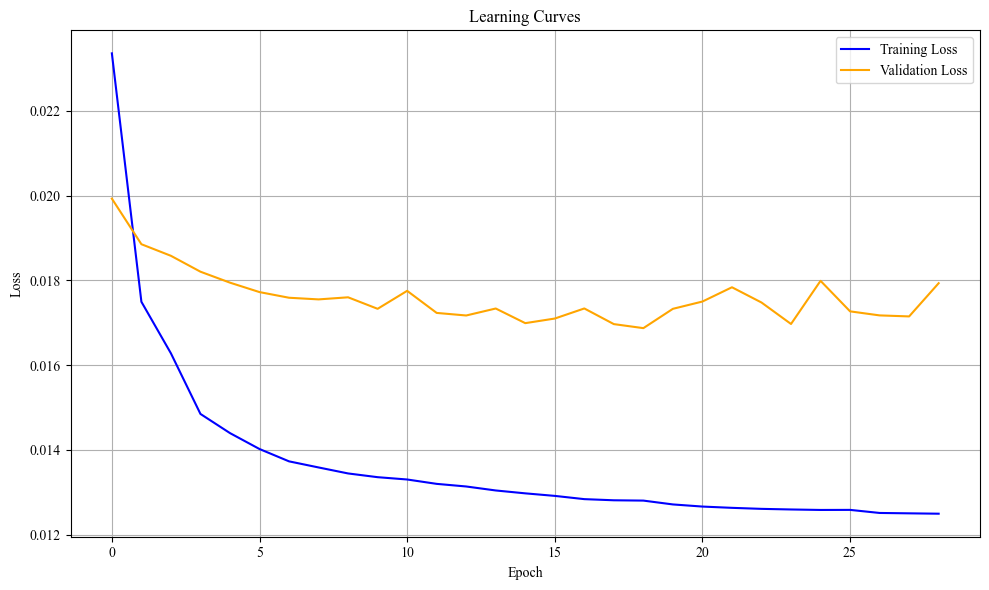

In [47]:
# Guardando los datos para plots en otro file de las curvas de aprendizaje
import matplotlib as mpl #para configurar los gráficos
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.size'] = 10


np.save(os.path.join(RESULTS_DIR, f"train_losses_{name}.npy"), np.array(train_losses))
np.save(os.path.join(RESULTS_DIR, f"val_losses_{name}.npy"), np.array(val_losses))

# Graficar las curvas de aprendizaje
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss", color="blue")
plt.plot(val_losses, label="Validation Loss", color="orange")
plt.title("Learning Curves")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, f"learning_curve_{name}.png"))
plt.show()


### Evaluación y error

C:\Users\adria\AppData\Local\Temp\ipykernel_22776\3442951059.py:78: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(PTH_DIR)) #esto es para añ


📊 Test Prediction (NORMALIZED):
MAE: 0.0982, RMSE: 0.1313, R²: 0.1804
Correlation (normalized) ECRL: 0.5518
Correlation (normalized) FCR: 0.4310
Correlation mean (normalized): 0.4914


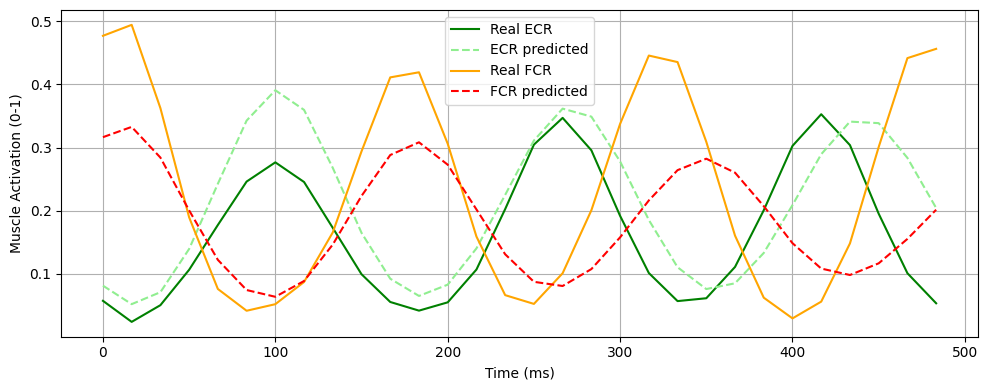

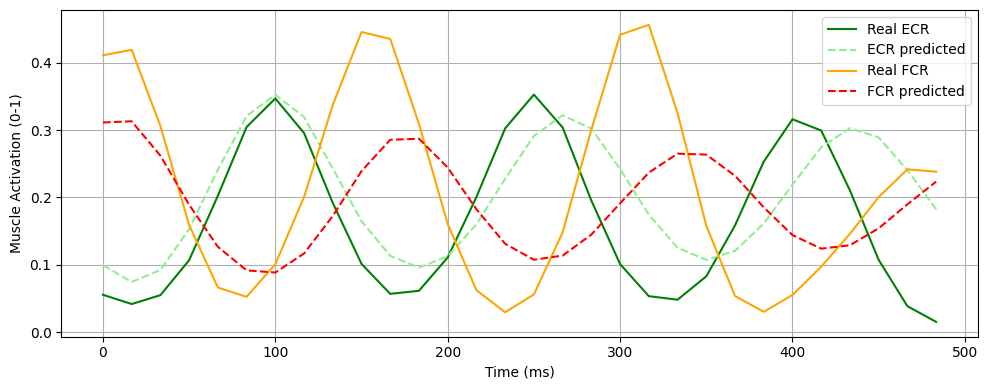

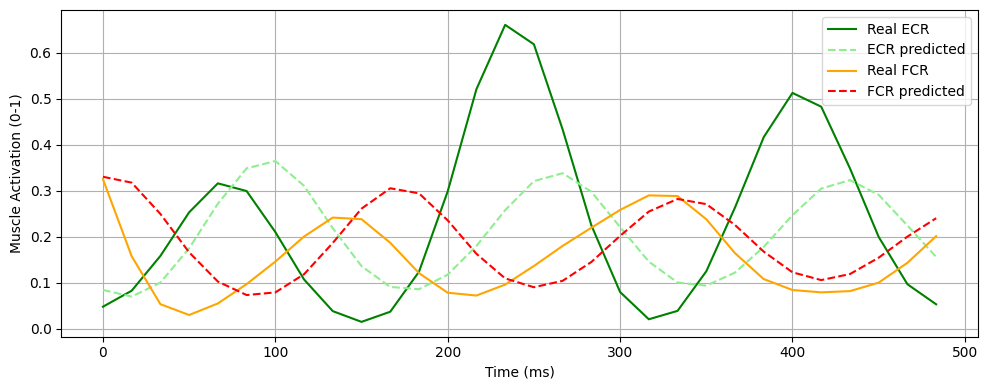

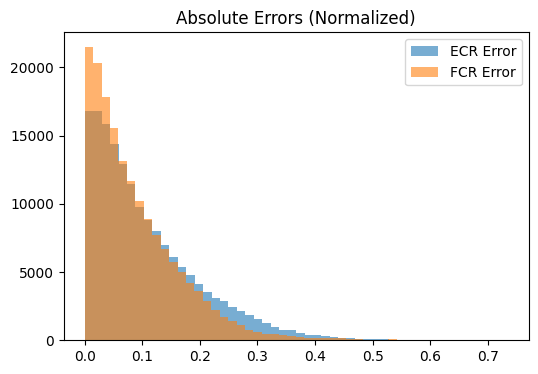

X_train shape: (26851, 60), y_train shape: (26851, 30, 2)
X_val shape: (3796, 60), y_val shape: (3796, 30, 2)
y_train min: 0.0, max: 1.0
Input scaler min: [-4.840764], max: [5.096766]
Output scaler min: [0. 0.], max: [138.69743  104.903915]

📊 Train Prediction (NORMALIZED):
MAE: 0.0806, RMSE: 0.1114, R²: 0.4357
Correlation (normalized) ECRL: 0.6784
Correlation (normalized) FCR: 0.6421
Correlation mean (normalized): 0.6603


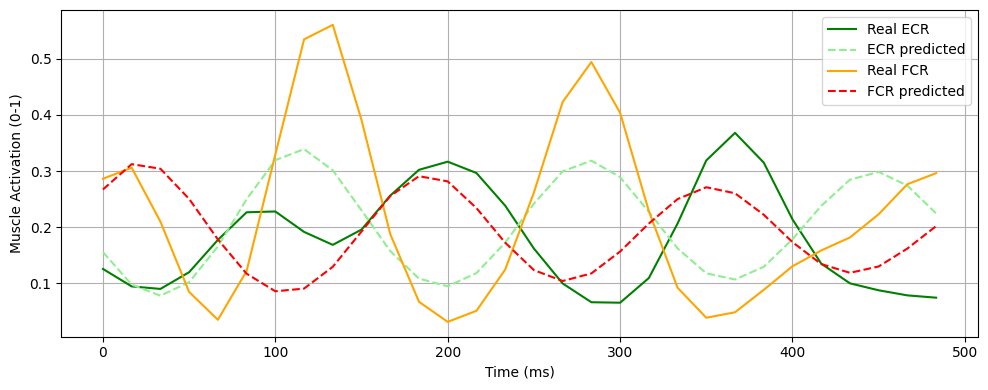

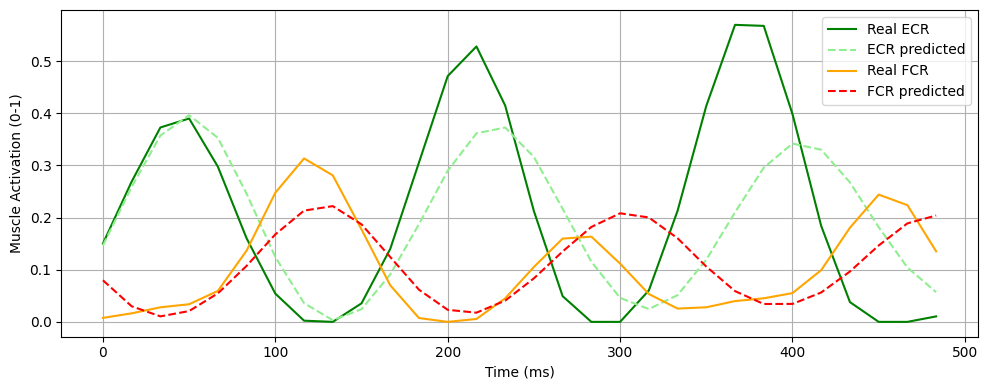

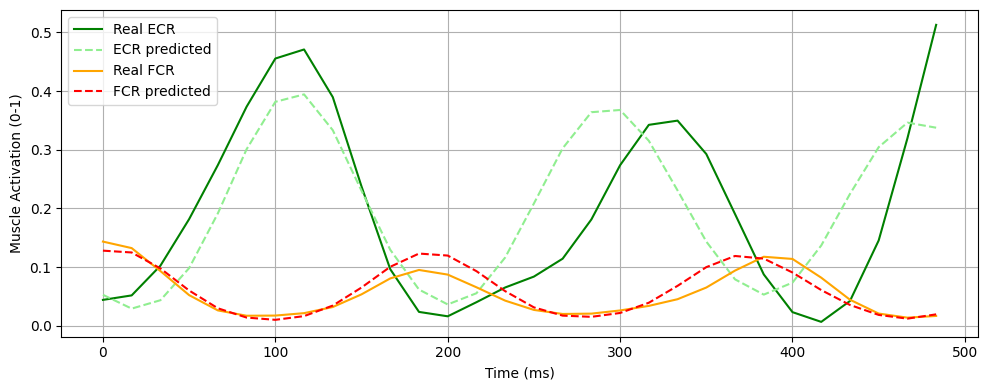

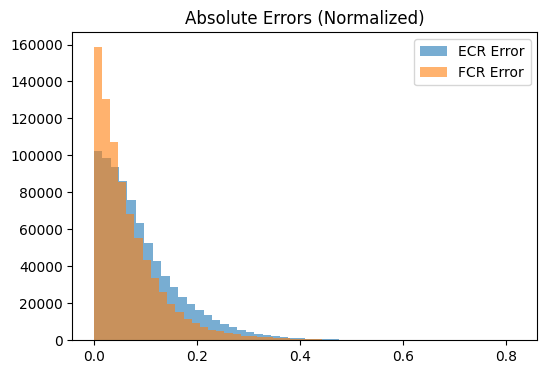


📊 Validation Prediction (NORMALIZED):
MAE: 0.0981, RMSE: 0.1301, R²: 0.4128
Correlation (normalized) ECRL: 0.6811
Correlation (normalized) FCR: 0.6055
Correlation mean (normalized): 0.6433


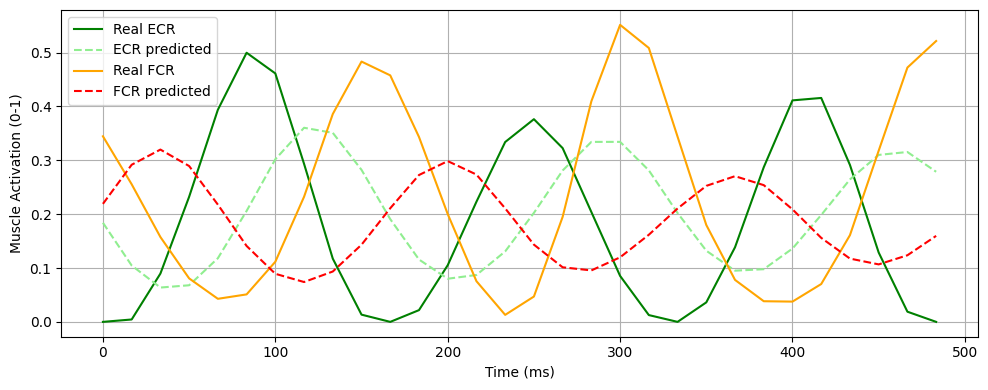

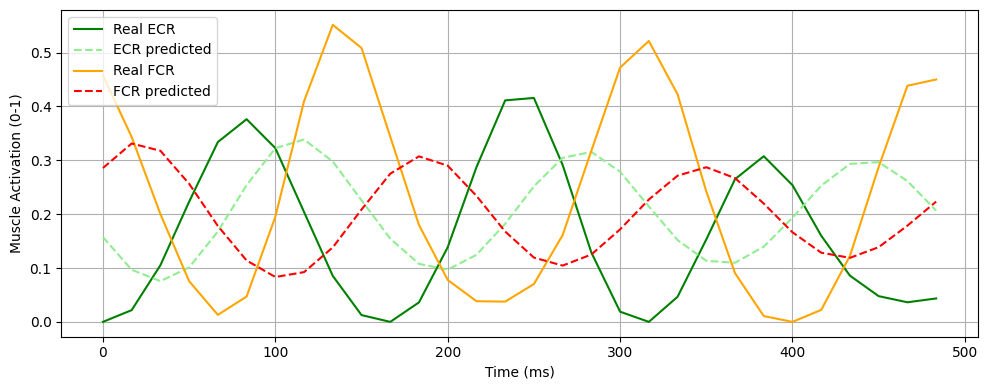

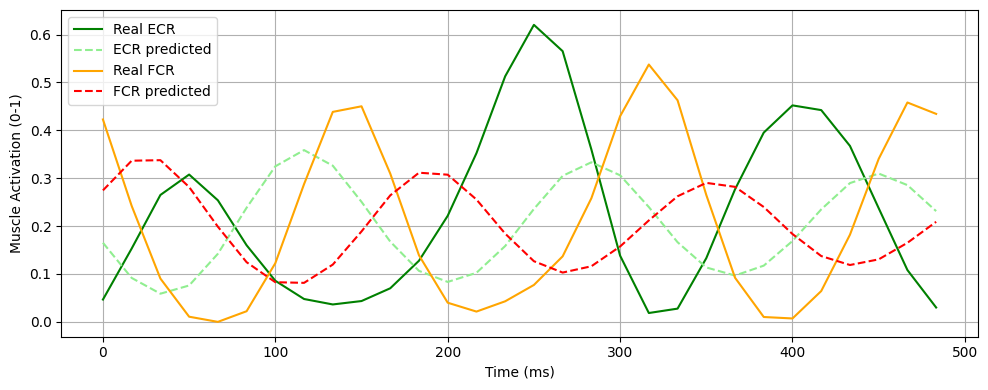

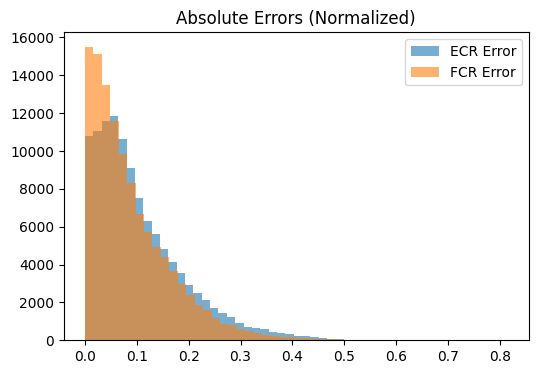

In [ ]:
def evaluate_and_plot(loader, title="Evaluación"):
    model.eval()
    all_preds, all_trues = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())

    # 1. Mantener la estructura original para los plots (N, output_len, 2)
    y_pred_norm = np.concatenate(all_preds) #(Total_de_secuencias, 30, 2)
    y_true_norm = np.concatenate(all_trues) 



    # 2. Crear versiones aplanadas SOLO para las métricas globales
    flat_pred = y_pred_norm.reshape(-1, 2) #lo transforma a una matriz de dos columnas, ECR y FCR.
    flat_true = y_true_norm.reshape(-1, 2)

    # Métricas
    mae = mean_absolute_error(flat_true, flat_pred)
    rmse = np.sqrt(mean_squared_error(flat_true, flat_pred))
    r2 = r2_score(flat_true, flat_pred)

    corr_ecr = np.corrcoef(flat_true[:, 0], flat_pred[:, 0])[0, 1]
    corr_fcr = np.corrcoef(flat_true[:, 1], flat_pred[:, 1])[0, 1]
    corr_mean = np.nanmean([corr_ecr, corr_fcr])

    print(f"\n📊 {title} Prediction (NORMALIZED):")
    print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")
    print(f"Correlation (normalized) ECRL: {corr_ecr:.4f}")
    print(f"Correlation (normalized) FCR: {corr_fcr:.4f}")
    print(f"Correlation mean (normalized): {corr_mean:.4f}")


    def plot_example(i):
        y_real_sample = y_true_norm[i] 
        y_pred_sample = y_pred_norm[i]

        t = np.arange(output_len) * (1000 / 60)  # 60Hz

        plt.figure(figsize=(10, 4))
        plt.plot(t, y_real_sample[:, 0], label='Real ECR', color='green')
        plt.plot(t, y_pred_sample[:, 0], '--', label='ECR predicted', color='lightgreen')
        plt.plot(t, y_real_sample[:, 1], label='Real FCR', color='orange')
        plt.plot(t, y_pred_sample[:, 1], '--', label='FCR predicted', color='red')
        
        plt.xlabel("Time (ms)")
        plt.ylabel("Muscle Activation (0-1)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # Usamos y_true_norm para el len() porque conserva la estructura de ejemplos
    for i in [0, 10, 30]: #son las secuencias 0, 10 y 30. Cada secuencia contenia 60 de input y 30 de output para cada muscle.
        if i < len(y_true_norm):
            plot_example(i)

    # Histograma de errores usando los datos aplanados
    errors = np.abs(flat_pred - flat_true)
    plt.figure(figsize=(6, 4))
    plt.hist(errors[:, 0], bins=50, alpha=0.6, label="ECR Error")
    plt.hist(errors[:, 1], bins=50, alpha=0.6, label="FCR Error")
    plt.legend()
    plt.title("Absolute Errors (Normalized)")
    plt.show()

    return y_pred_norm, y_true_norm
# Evaluación
model.load_state_dict(torch.load(PTH_DIR)) #esto es para añadir el mejor modelo guardado y evaluar con ese modelo en lugar del último modelo entrenado. Si no se carga el modelo guardado, se evaluará el modelo tal como quedó al finalizar el entrenamiento, que podría no ser el mejor debido al sobreajuste o a la fluctuación de la pérdida en las últimas épocas.
y_pred_test, y_true_test = evaluate_and_plot(test_loader, "Test")
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

print(f"y_train min: {y_train.min()}, max: {y_train.max()}")

print(f"Input scaler min: {scaler_input.data_min_}, max: {scaler_input.data_max_}")
print(f"Output scaler min: {scaler_output.data_min_}, max: {scaler_output.data_max_}")

y_pred_train, y_true_train = evaluate_and_plot(train_loader, "Train")
y_pred_val, y_true_val = evaluate_and_plot(val_loader, "Validation")


np.save("test_indices.npy", test_idx)
np.save("train_indices.npy", train_idx)
np.save("val_indices.npy", val_idx)


### Plot input vs output

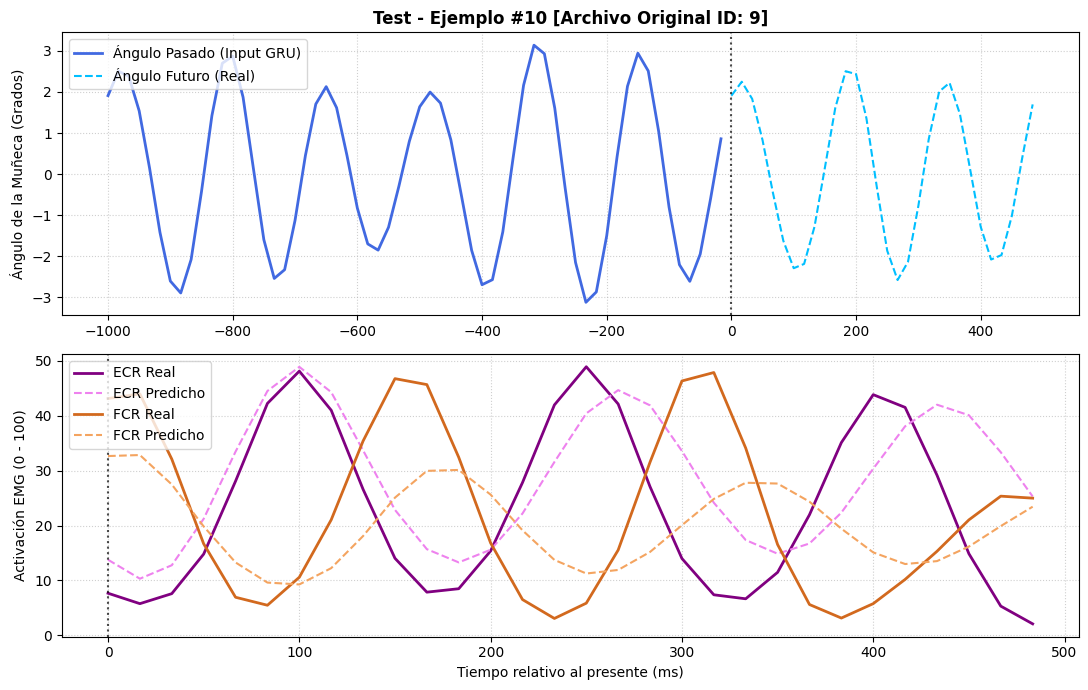

In [ ]:
def plot_input_output_clean(sample_idx=0, title="Test"):
    """
    1. Subplot Superior: Ángulo de la muñeca (Input Pasado + Input Futuro correspondiente).
    2. Subplot Inferior: Activaciones musculares (EMG Real vs Predicho) en el horizonte futuro.
    """
    fs = 60  # Hz 
    
    if title.lower() == "test":
        meta_data = meta_test
    elif title.lower() == "val":
        meta_data = meta_val
    else:
        meta_data = meta_train
        
    if sample_idx >= len(meta_data):
        print(f"❌ El índice {sample_idx} supera el tamaño de los datos de {title} (max: {len(meta_data)-1})")
        return

    signal_idx, start_idx = meta_data[sample_idx]

    full_raw_input = input_signals[signal_idx][80:]
    
    input_past_raw = full_raw_input[start_idx : start_idx + input_len]
    input_future_raw = full_raw_input[start_idx + input_len : start_idx + input_len + output_len]

    
    pred_emg_sample = scaler_output.inverse_transform(y_pred_test[sample_idx].reshape(-1, 2))
    true_emg_sample = scaler_output.inverse_transform(y_true_test[sample_idx].reshape(-1, 2))

    
    t_past = np.arange(-input_len, 0) * (1000 / fs)
    t_future = np.arange(0, output_len) * (1000 / fs)

    fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
    
    axes[0].plot(t_past, input_past_raw, color="royalblue", linewidth=2, label="Ángulo Pasado (Input GRU)")
    axes[0].plot(t_future, input_future_raw, color="deepskyblue", linewidth=1.5, linestyle="--", label="Ángulo Futuro (Real)")
    axes[0].axvline(0, color="black", linestyle=":", alpha=0.7) # Línea del "Presente"
    
    axes[0].set_title(f"{title} - Ejemplo #{sample_idx} [Archivo Original ID: {signal_idx}]", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("Ángulo de la Muñeca (Grados)", fontsize=10)
    axes[0].legend(loc="upper left")
    axes[0].grid(True, linestyle=":", alpha=0.6)

    axes[1].plot(t_future, true_emg_sample[:, 0], color="purple", linewidth=2, label="ECR Real")
    axes[1].plot(t_future, pred_emg_sample[:, 0], color="violet", linewidth=1.5, linestyle="--", label="ECR Predicho")
    axes[1].plot(t_future, true_emg_sample[:, 1], color="chocolate", linewidth=2, label="FCR Real")
    axes[1].plot(t_future, pred_emg_sample[:, 1], color="sandybrown", linewidth=1.5, linestyle="--", label="FCR Predicho")
    axes[1].axvline(0, color="black", linestyle=":", alpha=0.7) # Línea del "Presente"
    
    axes[1].set_xlabel("Tiempo relativo al presente (ms)", fontsize=10)
    axes[1].set_ylabel("Activación EMG (0 - 100)", fontsize=10)
    axes[1].legend(loc="upper left")
    axes[1].grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_input_output_clean(sample_idx=10, title="Test")

### Error por timestep

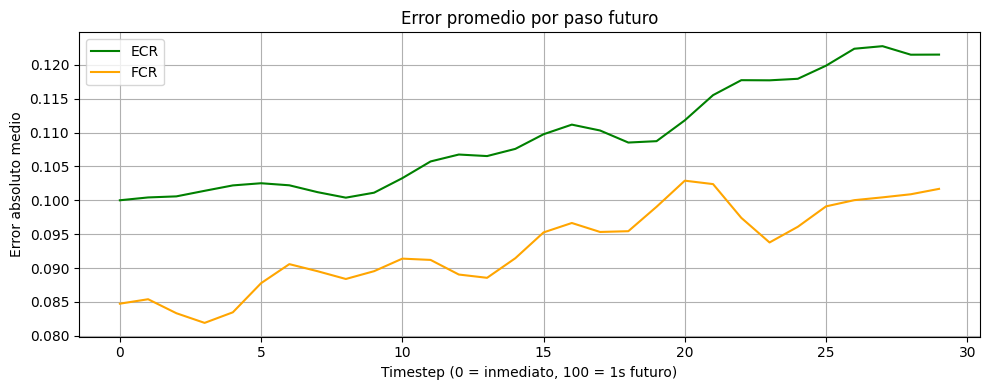

In [ ]:
errors = np.abs(y_pred_test - y_true_test)
mean_errors = errors.mean(axis=0)

t = np.arange(output_len)
plt.figure(figsize=(10, 4))
plt.plot(t, mean_errors[:, 0], label="ECR", color='green')
plt.plot(t, mean_errors[:, 1], label="FCR", color='orange')
plt.title("Error promedio por paso futuro")
plt.xlabel("Timestep (0 = inmediato, 100 = 1s futuro)")
plt.ylabel("Error absoluto medio")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [ ]:


def plot_error_analysis(y_pred, y_true, title="Test", results_dir=None, run_name=None):
    """
    Grafica el MAE por cada paso de tiempo futuro y el análisis mu/sigma.
    """
    r_dir = results_dir if results_dir is not None else RESULTS_DIR
    r_name = run_name if run_name is not None else name

    # 1. Error absoluto medio por timestep
    errors_by_step = np.abs(y_pred - y_true)
    mean_errors = errors_by_step.mean(axis=0)
    t = np.arange(output_len)  # 60Hz
    
    plt.figure(figsize=(10, 4))
    plt.plot(t, mean_errors[:, 0], label="ECRL", color='purple')
    plt.plot(t, mean_errors[:, 1], label="FCR", color='brown')
    plt.title(f"Mean error per future timestep ({title})", fontsize=16)
    plt.xlabel("Timestep", fontsize=14)
    plt.ylabel("Mean Absolute Error (MAE)", fontsize=14)
    plt.legend(loc="upper right", fontsize=12, frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(r_dir, f"Error_by_timestep_{title}_{r_name}.png"))
    plt.show()

    # 2. Distribución del error (Media y desviación estándar por timestep)
    errors = y_pred - y_true
    mu = errors.mean(axis=0)
    sigma = errors.std(axis=0)
    
    plt.figure(figsize=(10, 4))
    for i, label in enumerate(["ECRL", "FCR"]):
        color = 'purple' if i == 0 else 'brown'
        plt.plot(t, mu[:, i], label=f"μ {label}", color=color)
        plt.fill_between(t, mu[:, i] - sigma[:, i], mu[:, i] + sigma[:, i], alpha=0.2, label=f"μ±σ {label}")
        
    plt.xlabel("Timestep", fontsize=14)
    plt.ylabel("Error", fontsize=14)
    plt.legend(loc="upper right", fontsize=10, frameon=True)
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(os.path.join(r_dir, f"Error_mu_sigma_{title}_{r_name}.png"))
    plt.show()


def plot_input_output_pair(X_data, y_true_data, y_pred_data, index=100, title="Test", results_dir=None, run_name=None):
    """
    """
    r_dir = results_dir if results_dir is not None else RESULTS_DIR
    r_name = run_name if run_name is not None else name

    input_raw = X_data[index]
    input_real = scaler_input.inverse_transform(input_raw.reshape(-1, 1)).flatten()
    
    pred_emg = y_pred_data[index]
    real_emg = y_true_data[index]

    t_input = np.arange(-input_len, 0) * (1000 / 60)
    t_output = np.arange(0, output_len) * (1000 / 60)

    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax1.plot(t_input, input_real, color='blue', label='Angles', linewidth=1.5)
    ax1.set_ylabel("Wrist Flexion-Extension Angles (Degrees)", color='blue', fontsize=14)
    ax1.set_xlabel("Time (ms)", fontsize=14)
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.grid(False)

    ax2 = ax1.twinx()
    offset = 1.2 

    ax2.plot(t_output, pred_emg[:, 0] + offset, 'purple', linestyle='--', label='ECR predicted')
    ax2.plot(t_output, real_emg[:, 0] + offset, 'purple', label='ECR real', alpha=0.6)

    ax2.plot(t_output, pred_emg[:, 1], 'brown', linestyle='--', label='FCR predicted')
    ax2.plot(t_output, real_emg[:, 1], 'brown', label='FCR real', alpha=0.6)
    ax2.set_ylabel("Muscle Activation (0-1)", color='black', fontsize=14)
    ax2.tick_params(axis='y', labelcolor='black')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10, frameon=True)
    
    plt.tight_layout()
    plt.savefig(os.path.join(r_dir, f"Input_output_pair_{title}_{index}_{r_name}.png"))
    plt.show()

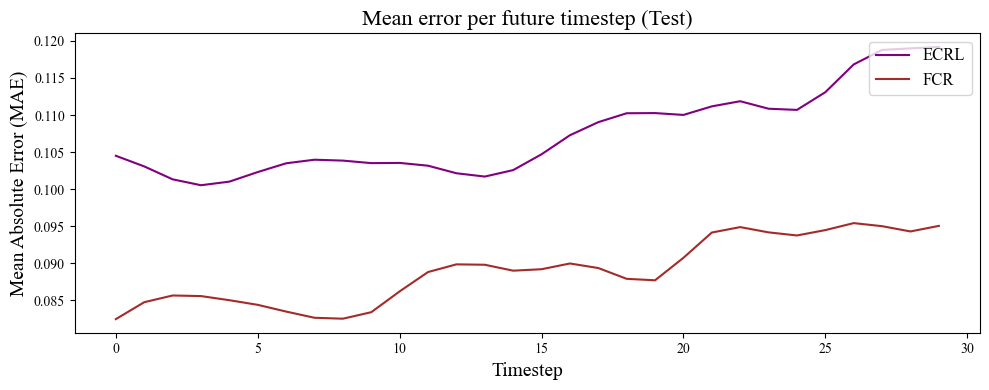

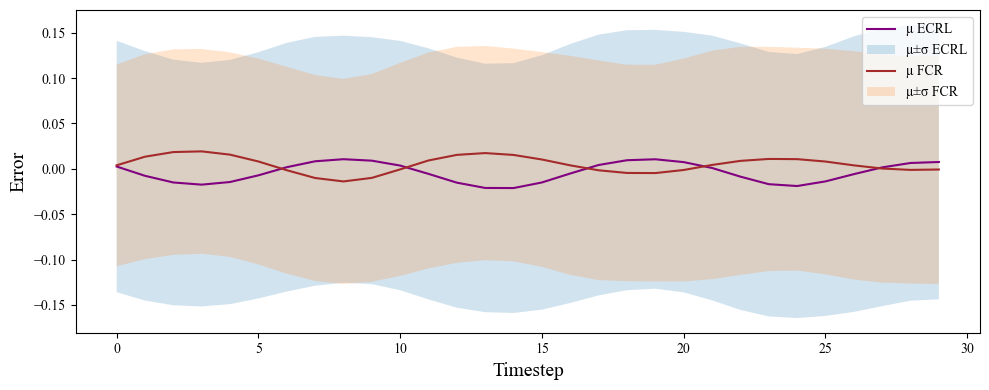

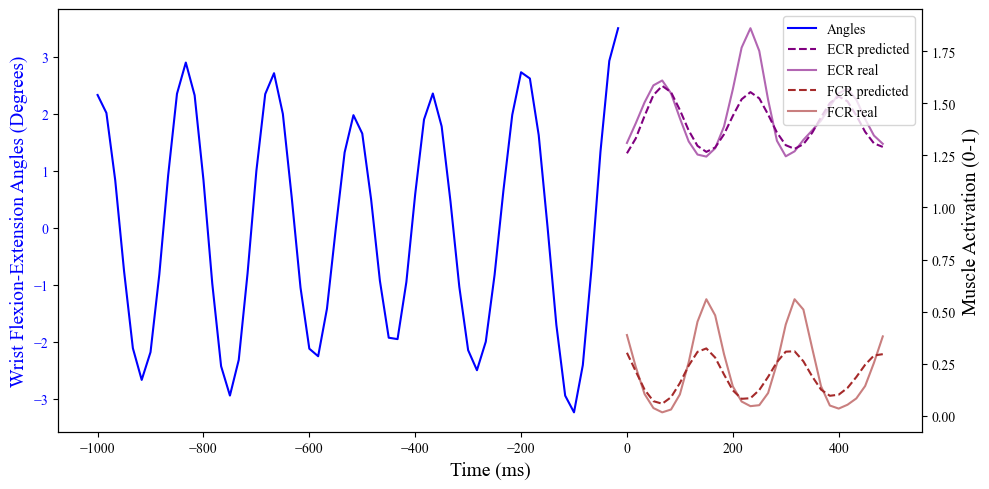

In [49]:
plot_error_analysis(y_pred_test, y_true_test, title="Test")
plot_input_output_pair(X_test, y_true_test, y_pred_test, index=100, title="Test")

### Debbuging

X_train shape: (26851, 60), y_train shape: (26851, 30, 2)
X_val shape: (3796, 60), y_val shape: (3796, 30, 2)
y_train min: 0.0, max: 1.0
Input scaler min: [-4.840764], max: [5.096766]
Output scaler min: [0. 0.], max: [138.69743  104.903915]

📊 Train Prediction (NORMALIZED):
MAE: 0.0806, RMSE: 0.1114, R²: 0.4357
Correlation (normalized) ECRL: 0.6784
Correlation (normalized) FCR: 0.6421
Correlation mean (normalized): 0.6603


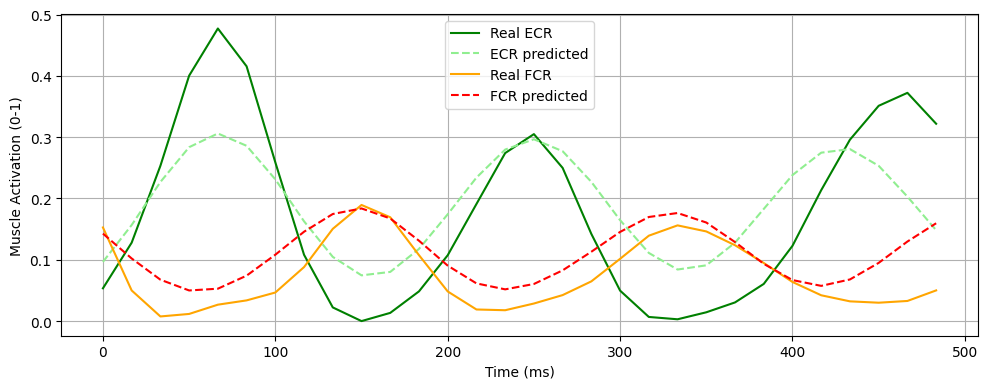

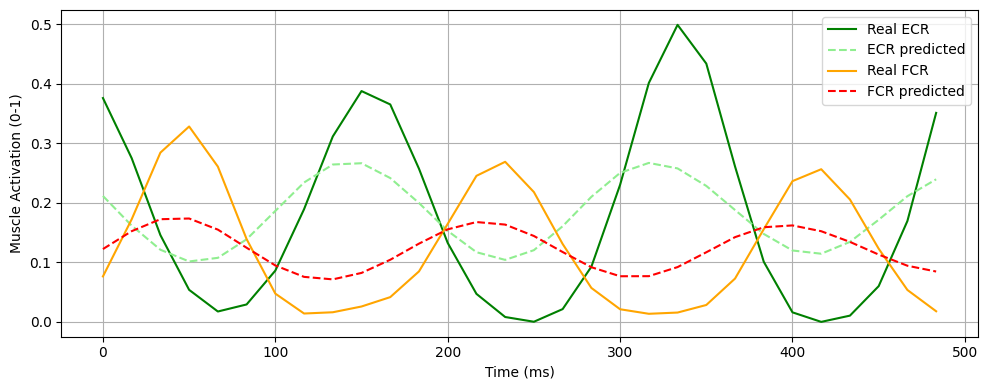

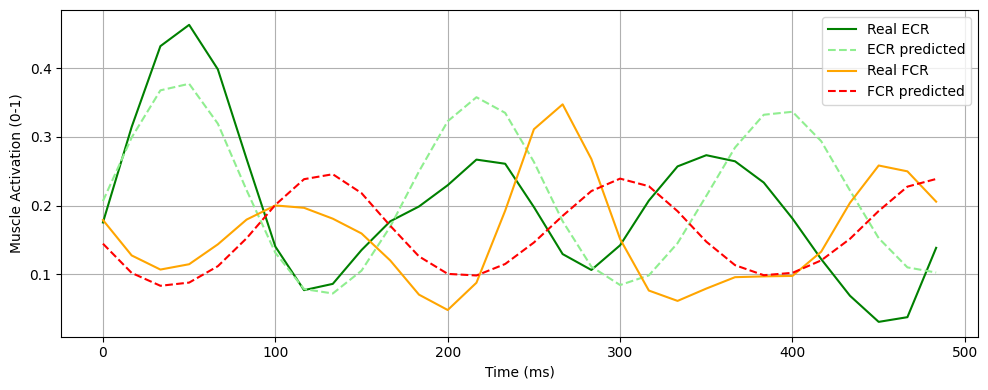

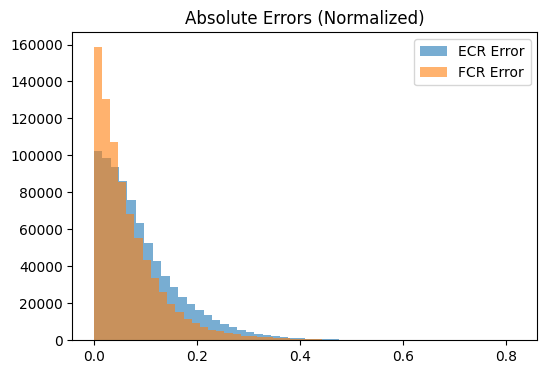

In [42]:

#Debugging

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")

print(f"y_train min: {y_train.min()}, max: {y_train.max()}")

print(f"Input scaler min: {scaler_input.data_min_}, max: {scaler_input.data_max_}")
print(f"Output scaler min: {scaler_output.data_min_}, max: {scaler_output.data_max_}")

y_pred_train, y_true_train = evaluate_and_plot(train_loader, "Train")


#-------------TEST------------------
# Evaluate on test set
def evaluate(loader):
    model.eval()
    all_preds, all_trues = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            pred = model(X_batch)
            all_preds.append(pred.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())
    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_trues)
    return y_pred, y_true

y_pred_test, y_true_test = evaluate(test_loader)

# Save predictions for later analysis/plotting
np.save(os.path.join(RESULTS_DIR, f"y_pred_test_{name}.npy"), y_pred_test)
np.save(os.path.join(RESULTS_DIR, f"y_true_test_{name}.npy"), y_true_test)

settings = {
    "batch_size": batch_size,
    "optimizer": "Adam",
    "learning_rate": 0.001,  # or your variable if it's not hardcoded
    "num_layers": 2,         # or your variable
    "dropout": 0.17499273890161493,  # or your variable
    "hidden_dim": 50,        # or your variable
    "input_len": input_len,
    "output_len": output_len,
    "epochs": 120,
    "patience": patience,
    "seed": 42
}

with open(os.path.join(RESULTS_DIR, f"settings_{name}.json"), "w") as f:
    json.dump(settings, f, indent=4)

np.save(os.path.join(RESULTS_DIR, f"test_indices_{name}.npy"), test_idx)
np.save(os.path.join(RESULTS_DIR, f"train_indices_{name}.npy"), train_idx)
np.save(os.path.join(RESULTS_DIR, f"val_indices_{name}.npy"), val_idx)
